# **Step1. 상품 리뷰 감성 분류**

**미션 : 리뷰마다 긍/부정 감성분석하기**
1) 목표 : 리뷰를 긍, 부정으로 분류하는 모델 생성
사전학습 모델을 파인 튜닝하여 모델 성능 높이기
2) 절차
    * 데이터 전처리
        - 긍/부정 분류를 위한 데이터셋 구성
        - 데이터 불균형 문제 해결하기
    * 사전학습 모델 파인 튜닝 : klue/bert-base 사용 권장
3) 최소 4가지 이상의 실험을 구성하고 수행하고 성능 비교
    * 학습 + 검증 데이터 : 10만 건 중 일부를 샘플링해서 수행.
    * 모델링 : 일반 파인튜닝, LoRA 파인튜닝 적용
    * 하이퍼파라미터 조정


## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')


* 함수 생성

In [ ]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [ ]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비① : 데이터 구조 만들기
* 아래와 같은 형태로 데이터 셋을 준비합니다.
    * 하나의 리뷰 문장에 하나의 긍/부정 값 지정
    * 리뷰별 label의 평균 값 >= 0.5 ➔ 긍정(1)

* 데이터 불균형을 확인하고 조치합니다.

### (1) 데이터 불러오기
* 제공 받은 'data.csv' 파일을 불러 옵니다.

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
data = pd.read_csv('data.csv')

In [ ]:
data

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1
1,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,품질,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,보습,1
3,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,포장,0
4,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,기타,1
...,...,...,...
107083,항상 사용하는 제품입니다. 가격 저렴하고 용량도 커서 오래 두고 사용하기 좋아요. ...,밀착,1
107084,상품 잘 받았습니다. 제형이 묽어서 흡수도 빠르지만 흡수 되고 나서 보습이 좋아 촉...,보습,1
107085,상품 잘 받았습니다. 제형이 묽어서 흡수도 빠르지만 흡수 되고 나서 보습이 좋아 촉...,피부,1
107086,상품 잘 받았습니다. 제형이 묽어서 흡수도 빠르지만 흡수 되고 나서 보습이 좋아 촉...,기타,1


### (2) 데이터 구조 만들기

* 다음과 같은 형태로 리뷰별 데이터 구조를 만듭니다.

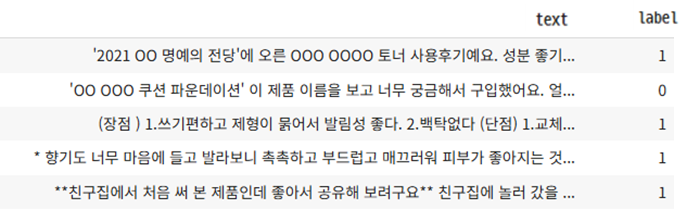

In [ ]:
review = data.groupby('text', as_index=False)['label'].mean()

review['label'] = (review['label'] >= 0.5).astype(int)

print(review.head())

                                                text  label
0  '2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...      1
1  '2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...      1
2  'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...      0
3  (장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...      1
4  * 향기도 너무 마음에 들고 발라보니 촉촉하고 부드럽고 매끄러워 피부가 좋아지는 것...      1


### (3) 데이터 불균형 해결하기

* label의 분포 확인하기

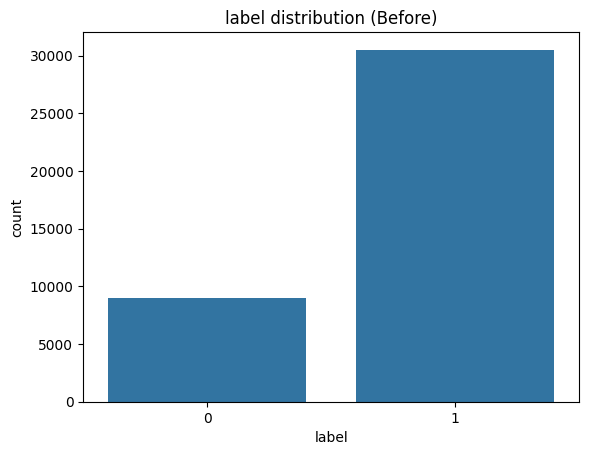

In [ ]:
sns.countplot(x='label', data = review)
plt.title('label distribution (Before)')
plt.show()

* label이 0과 1인 인 경우 각각 샘플링 2000건씩
    * 더 많이 할 수도 있지만 학습 시간을 고려


In [ ]:
# 데이터 샘플링
# df_1 = df.loc[df['label']==1].sample(2000)
# df_0 = df.loc[df['label']==0].sample(2000)
# data_0 = pd.concat([df_1, df_0], axis=0)

review_sample = pd.concat([
    review[review['label'] == 0].sample(n= 2000, random_state= 42),
    review[review['label'] == 1].sample(n= 2000, random_state= 42)
])

In [ ]:
# 데이터 분포 다시 확인
review_sample = review_sample.sample(frac=1, random_state=42).reset_index(drop=True)

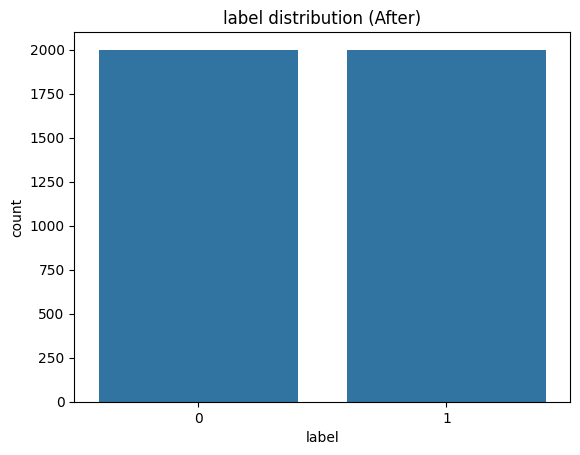

In [ ]:
sns.countplot(x='label', data=review_sample)
plt.title('label distribution (After)')
plt.show()

In [ ]:
print(review_sample['label'].value_counts())

label
0    2000
1    2000
Name: count, dtype: int64


## 3.데이터 준비② : 데이터 전처리

### (1) Dataset 만들기 : train, val
* train_test_split 함수 이용

In [ ]:
train, val = train_test_split(
    review_sample,
    test_size = 0.2,
    stratify = review_sample['label'],
    random_state = 42
)

* 텐서 데이터셋 만들기

In [ ]:
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

### (2) 토크나이징
* 모델 : "klue/bert-base"

In [ ]:
# 모델과 토크나이저 불러오기
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
# 토큰화 함수 생성 및 작업
def tokenize_function(example) :
  return tokenizer(
      example["text"],
      padding = "max_length",
      truncation = True,
      max_length = 128
  )

In [ ]:
train_ts = train_ts.map(tokenize_function, batched=True)
val_ts = val_ts.map(tokenize_function, batched=True)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

## 4.Fine-Tuning ①
* 일반 파인 튜닝 수행

### (1) 사전학습 모델 준비

In [ ]:
# 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2  # 긍정, 부정
)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [ ]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=50,
    save_total_limit=2,
    report_to="none"
)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

In [ ]:
# Trainer 설정
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    compute_metrics = compute_metrics,
)

### (3) 학습

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.226400,0.268200,0.903750,0.903293
2,0.121400,0.270883,0.912500,0.912498
3,0.090300,0.378177,0.918750,0.918704
4,0.018600,0.385760,0.920000,0.919992


TrainOutput(global_step=800, training_loss=0.12145271763205528, metrics={'train_runtime': 490.5296, 'train_samples_per_second': 26.094, 'train_steps_per_second': 1.631, 'total_flos': 841955377152000.0, 'train_loss': 0.12145271763205528, 'epoch': 4.0})

### (4) 모델 검증평가

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.38575980067253113, 'eval_accuracy': 0.92, 'eval_f1': 0.9199919991999201, 'eval_runtime': 5.4642, 'eval_samples_per_second': 146.407, 'eval_steps_per_second': 9.15, 'epoch': 4.0}


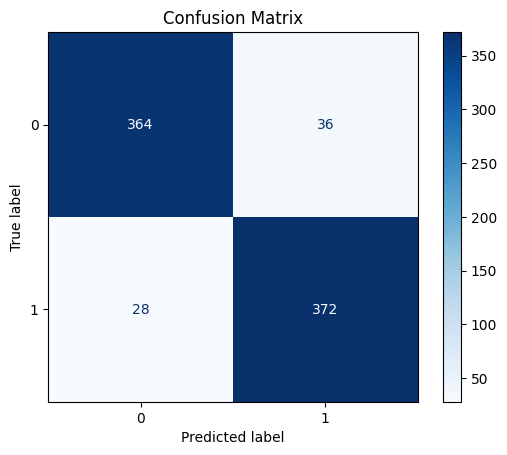

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       400
           1       0.91      0.93      0.92       400

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

preds_output = trainer.predict(val_ts)

y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


print("Classification Report")
print(classification_report(y_true, y_pred, target_names=["0", "1"]))


## 5.Fine-Tuning②
* LoRA(Low-Rank Adaptation)

### (1) 사전학습 모델 준비
* 위에서 적용한 내용

In [ ]:
# 모델 로드
model2 = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2  # 긍정, 부정
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) LoRA 구성

In [ ]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["query", "key", "value"],
    bias="none"
)

# LoRA 적용 (일부 레이어만 학습)
model = get_peft_model(model2, lora_config)


### (3) 학습

In [ ]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir="./lora_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,               # 초기 학습률 점진 증가
    gradient_accumulation_steps=2,  # batch 효과 확장
    load_best_model_at_end=True,
    logging_dir="./lora_logs",
    logging_steps=50,
    report_to="none"                 # wandb 비활성화
)

# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가)

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

trainer = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_ts,
    eval_dataset=val_ts,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [ ]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.552500,0.427285,0.876250,0.876248
2,0.272700,0.282186,0.893750,0.893677
3,0.214600,0.267240,0.903750,0.903732
4,0.241600,0.266871,0.903750,0.903743


TrainOutput(global_step=400, training_loss=0.3477965497970581, metrics={'train_runtime': 317.6728, 'train_samples_per_second': 40.293, 'train_steps_per_second': 1.259, 'total_flos': 846319150694400.0, 'train_loss': 0.3477965497970581, 'epoch': 4.0})

### (4) 모델 검증평가

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.2668713331222534, 'eval_accuracy': 0.90375, 'eval_f1': 0.903742630295132, 'eval_runtime': 5.2683, 'eval_samples_per_second': 151.852, 'eval_steps_per_second': 4.745, 'epoch': 4.0}


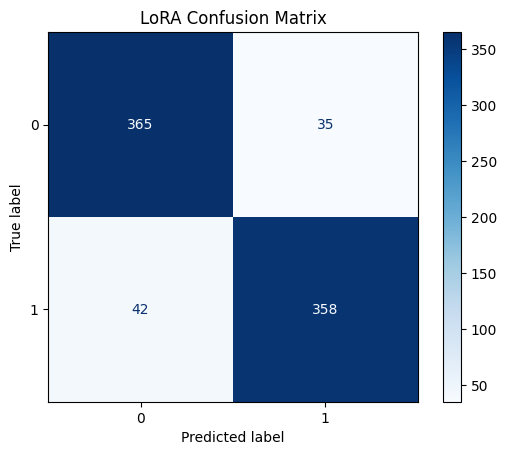

Classification Report (LoRA）
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       400
           1       0.91      0.90      0.90       400

    accuracy                           0.90       800
   macro avg       0.90      0.90      0.90       800
weighted avg       0.90      0.90      0.90       800



In [ ]:
preds_output = trainer.predict(val_ts)

y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("LoRA Confusion Matrix")
plt.show()

print("Classification Report (LoRA）")
print(classification_report(y_true, y_pred, target_names=["0", "1"]))

# **Step2. Multi-label 분류**



**미션 : 리뷰에 포함된 11가지 속성을 검출하기(Multi-label Multi-Classification)**

1) 목표 : 리뷰 내용에서, 속성에 해당하는 내용이 등장하는지 분류하는
모델 생성
2) 절차
    * 데이터 전처리 : 주어진 데이터를 목표에 맞는 형태로 변환
    * 모델링 : 다중 레이블 분류 파인 튜닝
        * 일반 파인 튜닝
        * LoRA 파인 튜닝

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [ ]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

### (2) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

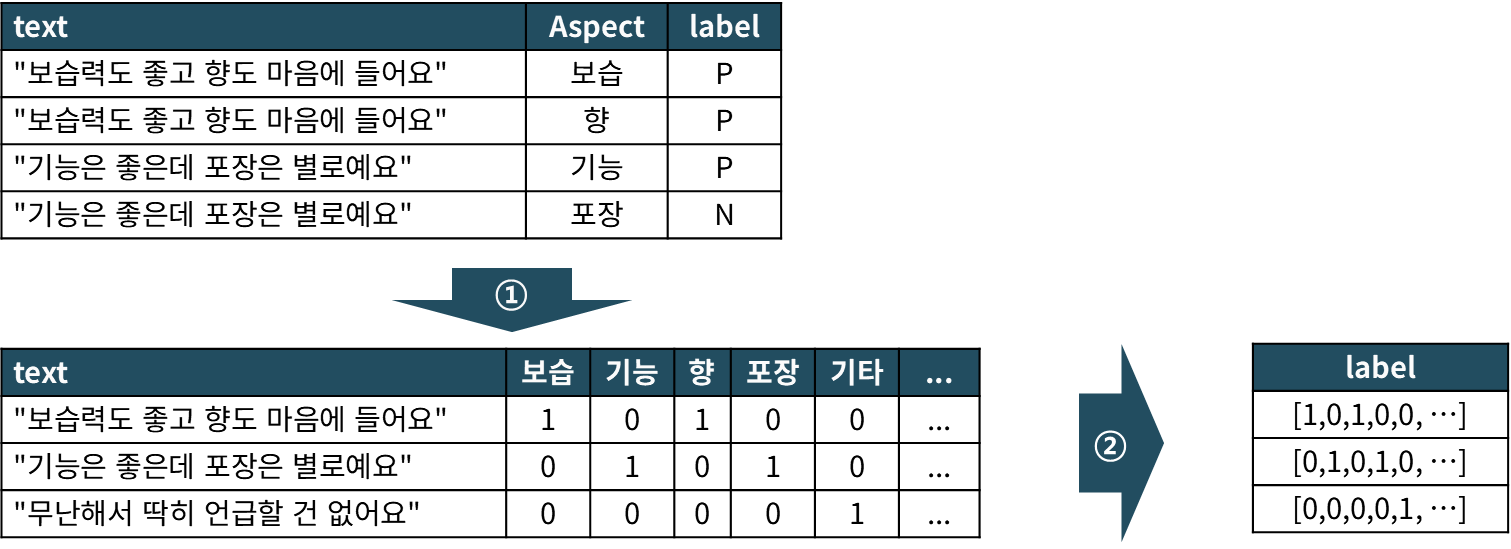

### (1) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
path = './data/'
df = pd.read_csv(path + 'data.csv')

### (2) Dataset 준비1

In [ ]:
# 레이블 리스트
labels = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* multi-hot label 만들기
    * multi-hot label 값이 문자열이 아닌 리스트여야 합니다.
* multi-hot label을 추가한 데이터셋을 data1 으로 저장합니다.

In [ ]:
df_drop = df.drop(columns=['label'])

In [ ]:
review = "'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기로 워낙 유명한 토너죠~ OO 명예의 전당에 오른 것도 놀랍지 않네요^^ 무색무취의 물 같은 제형으로 그냥 손바닥에만 덜어 봐도 무자극이란 느낌이 딱 와요. 그렇다고 단순히 닦아내 주기만 하는 게 아니라 피부에 부드럽게 흡수되면서 가벼운 보습감이 오래 지속된답니다. 500ml 대용량인데 손바닥에 덜기 불편한 용기라서 그 점만 좀 개선해 주면 더 좋겠어요. 피부 예민한 분들께 인생템이 되어줄 수 있는 제품으로 추천해 드려요^^"
df[df['text'].str.startswith(review)]

,text,aspect,label
75381,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,보습,1
75382,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,품질,1
75383,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,0
75384,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,1
75385,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,피부,1
75386,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,기타,1
75387,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,밀착,1


In [ ]:
# text와 aspect 컬럼 기준으로 중복 제거
df_unique = df.drop_duplicates(subset=['text', 'aspect']).reset_index(drop=True)

In [ ]:
review = "'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기로 워낙 유명한 토너죠~ OO 명예의 전당에 오른 것도 놀랍지 않네요^^ 무색무취의 물 같은 제형으로 그냥 손바닥에만 덜어 봐도 무자극이란 느낌이 딱 와요. 그렇다고 단순히 닦아내 주기만 하는 게 아니라 피부에 부드럽게 흡수되면서 가벼운 보습감이 오래 지속된답니다. 500ml 대용량인데 손바닥에 덜기 불편한 용기라서 그 점만 좀 개선해 주면 더 좋겠어요. 피부 예민한 분들께 인생템이 되어줄 수 있는 제품으로 추천해 드려요^^"
df_unique[df_unique['text'].str.startswith(review)]

,text,aspect,label
74389,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,보습,1
74390,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,품질,1
74391,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,0
74392,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,피부,1
74393,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,기타,1
74394,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,밀착,1


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

data = df_unique.groupby('text')['aspect'].apply(list).reset_index()
data.head(1)

,text,aspect
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[보습, 품질, 포장, 피부, 기타, 밀착]"


In [ ]:
mlb = MultiLabelBinarizer(classes=labels)
multi_hot_array = mlb.fit_transform(data['aspect'])
data['label'] = [list(row) for row in multi_hot_array]
data.drop(columns=['aspect'], inplace=True)
data.head(3)
# ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1]"
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]"
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,"[1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0]"


* 검증 : 제대로 생성되었는지 다음 코드로 검증해 봅니다.

In [ ]:
review = "(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점)"
display(data[data['text'].str.startswith(review)])
display(df[df['text'].str.startswith(review)])

,text,label
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,"[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]"


,text,aspect,label
42656,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,밀착,1
42657,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,품질,0
42658,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,기타,1
42659,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,편의성,1
42660,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,향,1


* 전체 데이터에서 10000건을 샘플링 합니다.(파인튜닝 시간 절약을 위해서)

In [ ]:
# 데이터 샘플링
size = 10000
df_10k = data[:size]

### (3) Dataset 준비2
* train, val 분할 7:3
* 텐서 데이터셋

In [ ]:
# train, val 분할 7:3
from sklearn.model_selection import train_test_split

train, val = train_test_split(df_10k, test_size=0.3, random_state=42)

In [ ]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [ ]:
train_ts[:1]

{'text': ['도착하자마자 바로 사용했어요. 투명해지는데는 좀 오래 걸려요. 시원하고 피부가 쫀쫀해지는 느낌은 좋습니다. 선호하는 향은 아니지만 1일1 팩할 듯합니다. 가격은 더 저렴해지면 좋을 것 같아요.'],
 'label': [[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0]],
 '__index_level_0__': [9069]}

### (4) 토크나이징

* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

In [ ]:
# 토크나이저 다운로드
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함
def preprocess_function(examples):
    # tokenizer 적용
    encodings = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)
    # labels float 변환
    encodings['label'] = [list(map(float, l)) for l in examples['label']]
    return encodings

# 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map: 100%|██████████| 3000/3000 [00:00<00:00, 12195.11 examples/s]


## 3.Fine-Tuning1
* 일반 파인 튜닝으로

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [ ]:
# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

* TrainArguments

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [ ]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:
# Trainer 설정 :
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator,  # 필수사항
    compute_metrics=compute_metrics,     # 선택사항
)

C:\Users\USER\AppData\Local\Temp\ipykernel_19016\245137270.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (3) 학습
* 7000건 학습데이터에 대해서, 학습 시간이 10~13분 정도 소요 됩니다.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1
1,0.306300,0.277684,0.768072,0.748239
2,0.207900,0.209421,0.857178,0.856570
3,0.176600,0.183116,0.874782,0.873170
4,0.163600,0.171677,0.884774,0.883007
5,0.142900,0.167974,0.886100,0.883560


TrainOutput(global_step=1095, training_loss=0.22669816877199633, metrics={'train_runtime': 152.1651, 'train_samples_per_second': 230.013, 'train_steps_per_second': 7.196, 'total_flos': 2302407770880000.0, 'train_loss': 0.22669816877199633, 'epoch': 5.0})

### (4) 모델 검증평가

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.16475017368793488, 'eval_runtime': 4.294, 'eval_samples_per_second': 698.65, 'eval_steps_per_second': 43.782, 'epoch': 10.0}


* 예측값

In [ ]:
pred_output = trainer.predict(val_ts)

In [ ]:
logits = pred_output.predictions
label_ids = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

sample_idx = 0
pred_sample = preds[sample_idx]
predicted_classes = [labels[i] for i, v in enumerate(pred_sample) if v == 1]
print("예측값 (multi-hot vector):", pred_sample)
print("예측된 클래스:", predicted_classes)

예측값 (multi-hot vector): [1 0 1 0 0 0 0 0 0 0 0]
예측된 클래스: ['보습', '밀착']


* 실제값

In [ ]:
true_sample = label_ids[sample_idx]
true_classes = [labels[i] for i, v in enumerate(true_sample) if v == 1]

print("실제값 (multi-hot vector):", true_sample)
print("실제 클래스:", true_classes)

실제값 (multi-hot vector): [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
실제 클래스: ['보습', '밀착']


* 평가

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    label_ids,
    preds,
    average=None,
    zero_division=0
)

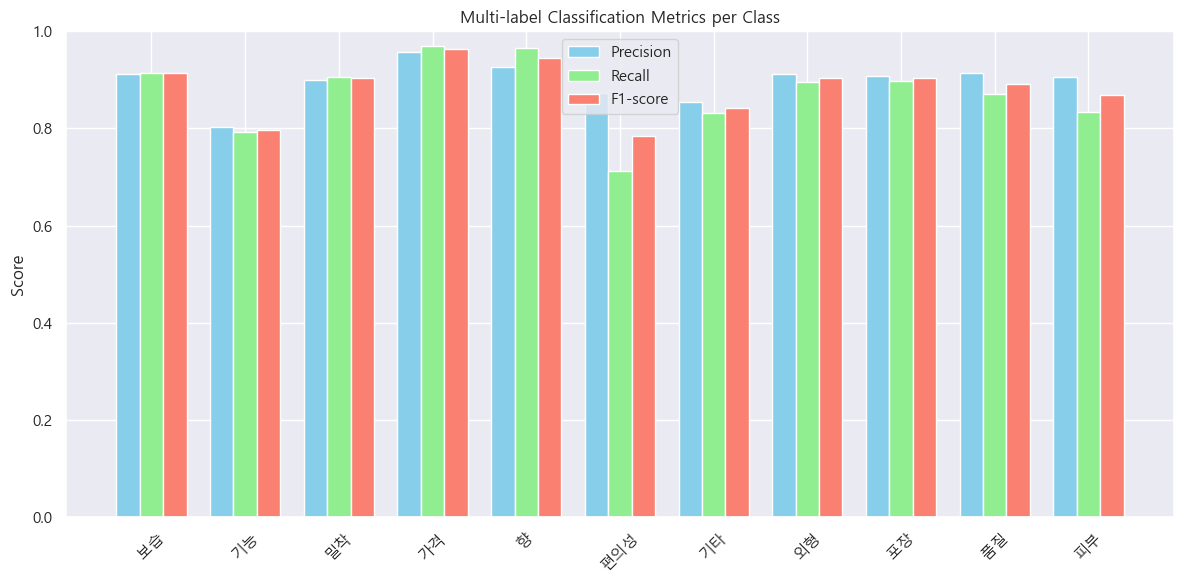

In [ ]:
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Multi-label Classification Metrics per Class')
plt.legend()
plt.tight_layout()
plt.show()


## 4.Fine-Tuning2
* LoRA 튜닝하기

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [ ]:
model_name = "klue/bert-base"
# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    encodings = tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )
    encodings['labels'] = [list(map(float, l)) for l in examples['label']]
    return encodings

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 3000/3000 [00:00<00:00, 12499.95 examples/s]


### (2) LoRA 구성

In [ ]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

# LoRA 적용
model = get_peft_model(model, lora_config)

### (3) 학습 설정

* TrainArguments
    * 일반 파인 튜닝보다는 학습률을 조금 높게 설정

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,
    per_device_train_batch_size = 8,   # 학습 배치 사이즈
    per_device_eval_batch_size = 16,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [ ]:
# 사용자 정의 data_collator 생
from torch.utils.data import DataLoader
from transformers import default_data_collator

def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator
)

C:\Users\USER\AppData\Local\Temp\ipykernel_3044\3448237408.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (4) 학습

In [ ]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.276800,0.272543
2,0.223400,0.212999
3,0.162200,0.191630
4,0.201100,0.181024
5,0.178300,0.174233
6,0.177800,0.170319
7,0.102600,0.168973
8,0.107200,0.165805
9,0.135700,0.165293
10,0.114600,0.164750


TrainOutput(global_step=8750, training_loss=0.18264093589782715, metrics={'train_runtime': 500.8915, 'train_samples_per_second': 139.751, 'train_steps_per_second': 17.469, 'total_flos': 4621124766720000.0, 'train_loss': 0.18264093589782715, 'epoch': 10.0})

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.16475017368793488, 'eval_runtime': 4.14, 'eval_samples_per_second': 724.638, 'eval_steps_per_second': 45.411, 'epoch': 10.0}


### (5) 모델 검증평가

In [ ]:
pred_output = trainer.predict(val_ts)
logits = pred_output.predictions
label_ids = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

sample_idx = 0
pred_sample = preds[sample_idx]
predicted_classes = [labels[i] for i, v in enumerate(pred_sample) if v == 1]
print("예측값 (multi-hot vector):", pred_sample)
print("예측된 클래스:", predicted_classes)

예측값 (multi-hot vector): [1 0 1 0 0 0 0 0 0 0 0]
예측된 클래스: ['보습', '밀착']


In [ ]:
true_sample = label_ids[sample_idx]
true_classes = [labels[i] for i, v in enumerate(true_sample) if v == 1]

print("실제값 (multi-hot vector):", true_sample)
print("실제 클래스:", true_classes)

실제값 (multi-hot vector): [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
실제 클래스: ['보습', '밀착']


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    label_ids,
    preds,
    average=None,
    zero_division=0
)

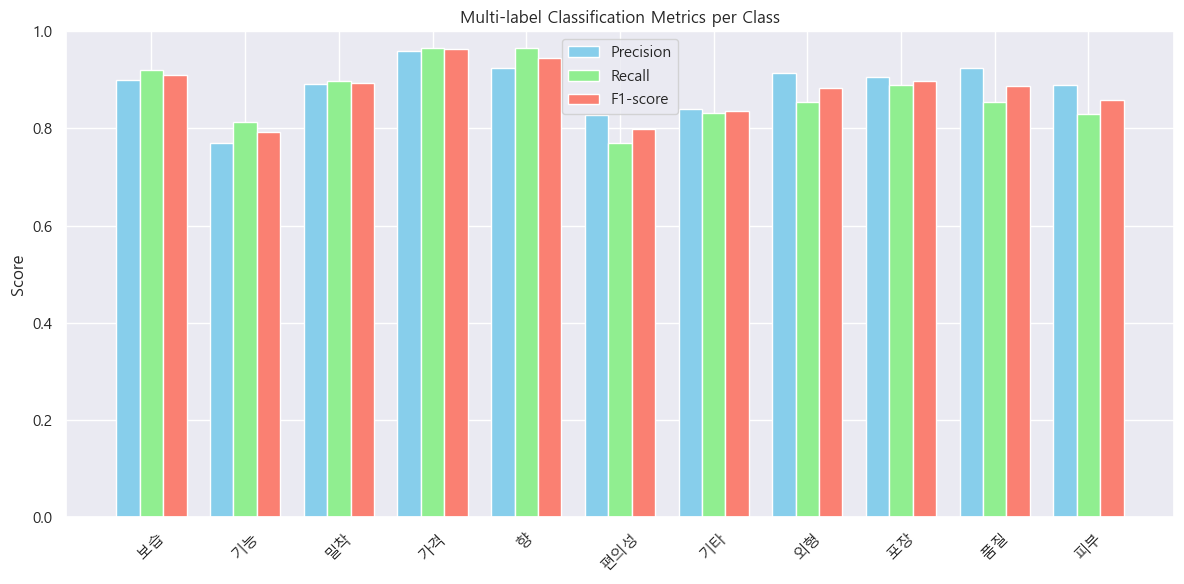

In [ ]:
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Multi-label Classification Metrics per Class')
plt.legend()
plt.tight_layout()
plt.show()


# **Step3. 속성 기반 감정 분류**

**미션 : 리뷰 안에 담긴 11가지 속성 감성 분석하기(Aspect-Based Sentiment Analysis)**
1) 목표 : 속성 기반 감성 분석을 통해, 리뷰 내용을 속성에 따라 긍, 부정
으로 분류하는 모델 생성
2) 절차① : “[ASPECT] 속성 [SEP] 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 스페셜 토큰 추가 + 모델의 임베딩 층 resizing
    * 파인튜닝 및 모델 평가
3) 절차② : “Aspect : 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 파인튜닝 및 모델 평가
4) 성능 비교 : “Aspect : 문장”
    * 모델 별 : klue/bert-base, klue/RoBERTa-base
    * 전처리 별 : Case①, Case②
    * Macro Recall, Macro Precision, Macro F1-Score 비교

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib
import matplotlib as mpl
import matplotlib.font_manager as fma
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fma.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

### (2) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (2).csv


In [ ]:
import io
import pandas as pd

data = pd.read_csv('data.csv')

* 전제 데이터 중 10,000건만 샘플링
    * 학습 속도 고려

In [ ]:
# 데이터 샘플링

data_sample = data.sample(n=10000,random_state=42)

data_sample.head()

,text,aspect,label
78839,일주일정도 사용 중인데 아직 효과는 없어요 끈적임이 조금 남아요,밀착,0
36074,원래쓰던 아이브로우가 품절이라 찾다가 직장 동료가 OO OOO 아이브로우 오토 펜슬...,외형,1
28761,주변에서 좋다고 추천하길래 구매해 봤습니다. 선물도 하려고 여러 개 구매했어요. 그...,향,0
50134,새로나온 OOO 궁금해서 주문했습니다 빠르게 배송 받고 오늘 써봤는데 촉촉하고 발림...,외형,1
70481,올인원이라 편리하고 기능이 참 많이 들어있다는 이야기에 혹해서 홀린 듯 구매했어요....,보습,0


### (3) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.방식① : [ASPECT] 속성 [SEP] 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "[ASPECT] 속성 [SEP] 문장" 형태로 수정
    * 토크나이징

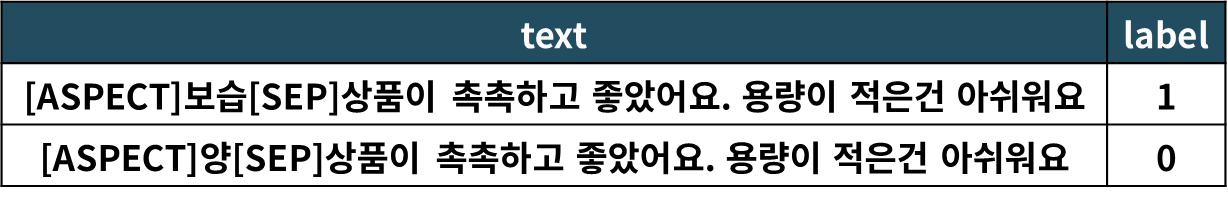

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
model_name1="klue/bert-base"
model_name2="klue/roberta-base"

In [ ]:
# train, val 데이터 분할
from sklearn.model_selection import train_test_split

train, val = train_test_split(data_sample, test_size=0.3,random_state=42)

In [ ]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

#### 2) 토크나이징
* "[ASPECT] 속성 [SEP] 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
tokenizer2 = AutoTokenizer.from_pretrained("klue/roberta-base")

* 사용자 정의 스페셜 토큰 등록하기

In [ ]:
# 사용자 정의 스페셜 토큰 목록
special_tokens_dict = {"additional_special_tokens":["[ASPECT]"]}

# 토크나이저에 추가
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
print(f"Added {num_added_toks} special tokens: {special_tokens_dict['additional_special_tokens']}")

num_added_toks2 = tokenizer2.add_special_tokens(special_tokens_dict)
print(f"Added {num_added_toks2} special tokens: {special_tokens_dict['additional_special_tokens']}")

Added 1 special tokens: ['[ASPECT]']
Added 1 special tokens: ['[ASPECT]']


In [ ]:
tokenizer

BertTokenizerFast(name_or_path='klue/bert-base', vocab_size=32000, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]', 'additional_special_tokens': ['[ASPECT]']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32000: AddedToken("[ASPECT]", rstrip=False, lstrip=False, single_word=False, normalized=False, sp

* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수
def preprocess_function(data):
  texts = [f"[ASPECT] {a} [SEP] {t}" for a, t in zip(data['aspect'], data['text'])]

  tokenized = tokenizer(
      texts,
      truncation=True,
      padding='max_length',
      max_length=128
  )

  tokenized['labels'] = [float(l) for l in data['label']]

  return tokenized

# 모델1 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

# 모델2 전처리 함수
def preprocess_function2(data):
  texts = [f"[ASPECT] {a} [SEP] {t}" for a, t in zip(data['aspect'], data['text'])]

  tokenized = tokenizer2(
      texts,
      truncation=True,
      padding='max_length',
      max_length=128
  )

  tokenized['labels'] = [float(l) for l in data['label']]

  return tokenized


# 모델2 전처리 적용
train_ts2= train_ts.map(preprocess_function2, batched=True)
val_ts2 = val_ts.map(preprocess_function2, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비
* 모델 로드한 후
* 반드시 `모델.resize_token_embeddings(len(tokenizer))`

In [ ]:
# 모델1

num_labels = 2

model1 = AutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=num_labels
)

model1.resize_token_embeddings(len(tokenizer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=0)

In [ ]:
# 모델2

model2 = AutoModelForSequenceClassification.from_pretrained(
    model_name2,
    num_labels=num_labels
)

model2.resize_token_embeddings(len(tokenizer))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [ ]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:

# Trainer1 설정
trainer = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    #data_collator=float_label_collator,  # 오류 자주 발생.
    #compute_metrics=compute_metrics,     # 추가 측정 지표
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)


# Trainer2 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts2,
    eval_dataset = val_ts2,
    tokenizer = tokenizer2,
    #data_collator=float_label_collator,  # 오류 자주 발생.
    #compute_metrics=compute_metrics,     # 추가 측정 지표
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

/tmp/ipython-input-450870664.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/tmp/ipython-input-450870664.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [ ]:
print(model1.config.problem_type)

None


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.191900,0.215580
2,0.128000,0.167412
3,0.101400,0.212826
4,0.027200,0.260007
5,0.030900,0.285079


TrainOutput(global_step=1095, training_loss=0.11828905225106298, metrics={'train_runtime': 954.0337, 'train_samples_per_second': 36.686, 'train_steps_per_second': 1.148, 'total_flos': 2302221734400000.0, 'train_loss': 0.11828905225106298, 'epoch': 5.0})

In [ ]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.217200,0.272216
2,0.130400,0.171281
3,0.110100,0.195706
4,0.030900,0.233337
5,0.034200,0.235283


TrainOutput(global_step=1095, training_loss=0.13641407039339684, metrics={'train_runtime': 959.0933, 'train_samples_per_second': 36.493, 'train_steps_per_second': 1.142, 'total_flos': 2302221734400000.0, 'train_loss': 0.13641407039339684, 'epoch': 5.0})

#### 4) 모델 검증평가

* 예측

In [ ]:
raw_pred1 = trainer.predict(val_ts)

In [ ]:
pred1 = raw_pred1.predictions.argmax(axis=1) #1,0으로 변
true1 = raw_pred1.label_ids # 정답 1,0

In [ ]:
raw_pred2 = trainer2.predict(val_ts2)

In [ ]:
pred2 = raw_pred2.predictions.argmax(axis=1)
true2 = raw_pred2.label_ids

* 평가 : model1

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(true1, pred1, target_names=['부정','긍정'])
print(report)



              precision    recall  f1-score   support

          부정       0.93      0.83      0.87       830
          긍정       0.94      0.98      0.96      2170

    accuracy                           0.93      3000
   macro avg       0.93      0.90      0.91      3000
weighted avg       0.93      0.93      0.93      3000



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val1 = val_ts.to_pandas()
val1['pred'] = pred1

# 일부 결과 확인
val1[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,ㅇㅇㅇ선스틱이 유명 한 건 알았는데 이전에 있는 제품은 끈적임이 있어서 개인적으로 ...,기능,1,1
1,여름 태양으로부터 모발을 보호하려고 구매했습니다. 냄새도 좋아요. 머릿결도 부드럽습...,향,1,1
2,어제 받아서 써봤는데 좋아요~ 엄청 촉촉하고 여기저기 쓱쓱 바르기 편해요 사이즈도 ...,보습,1,1
3,가성비좋아요 향도좋네요 묻어나네요ㅜ 시간 지나니 안묻어나네요ㅎ,가격,1,1
4,향이 가벼워서 아쉬운 것 같습니다. 겨울에는 사용하기 안 좋은 것 같습니다. 괜히 ...,향,0,0


In [ ]:
# DataFrame 준비
df_eval = val1.copy()

aspect_scores = []

for aspect, group in df_eval.groupby('aspect'):
  y_true = group['label']
  y_pred = group['pred']
  p = precision_score(y_true, y_pred, zero_division=0)
  r = recall_score(y_true, y_pred, zero_division=0)
  f = f1_score(y_true, y_pred, zero_division=0)
  aspect_scores.append({'aspect': aspect, 'precision': p, 'recall': r, 'f1': f})

aspect_df = pd.DataFrame(aspect_scores)
display(aspect_df)

,aspect,precision,recall,f1
0,가격,0.980583,0.952830,0.966507
1,기능,0.960000,0.939759,0.949772
2,기타,0.855072,0.907692,0.880597
3,밀착,0.927419,0.982906,0.954357
4,보습,0.951807,0.975309,0.963415
5,외형,0.891892,0.891892,0.891892
6,편의성,0.963134,0.995238,0.978923
7,포장,0.927007,0.933824,0.930403
8,품질,0.948905,0.977444,0.962963
9,피부,0.960396,0.979798,0.970000


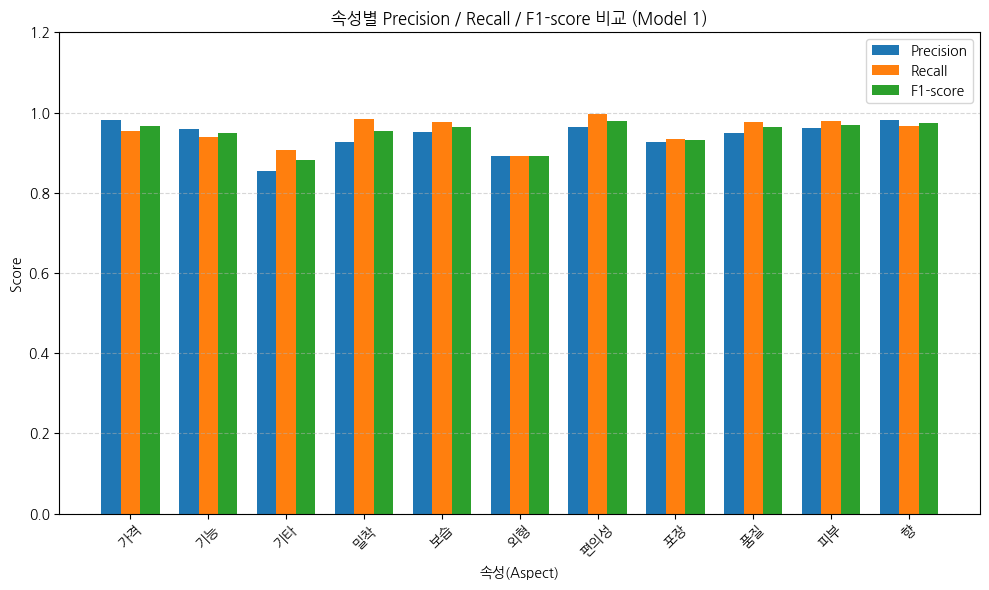

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
x = np.arange(len(aspect_df['aspect']))
width = 0.25

plt.bar(x - width, aspect_df['precision'], width, label='Precision')
plt.bar(x, aspect_df['recall'], width, label='Recall')
plt.bar(x + width, aspect_df['f1'], width, label='F1-score')

plt.xticks(x, aspect_df['aspect'], rotation=45)
plt.xlabel('속성(Aspect)')
plt.ylabel('Score')
plt.title('속성별 Precision / Recall / F1-score 비교 (Model 1)')
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

* 평가 : model2

In [ ]:
report = classification_report(true2, pred2, target_names=['부정','긍정'])
print(report)

              precision    recall  f1-score   support

          부정       0.89      0.88      0.88       830
          긍정       0.95      0.96      0.96      2170

    accuracy                           0.94      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.94      0.94      0.94      3000



In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val2 = val_ts2.to_pandas()
val2['pred'] = pred2

# 일부 결과 확인
val2[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,ㅇㅇㅇ선스틱이 유명 한 건 알았는데 이전에 있는 제품은 끈적임이 있어서 개인적으로 ...,기능,1,1
1,여름 태양으로부터 모발을 보호하려고 구매했습니다. 냄새도 좋아요. 머릿결도 부드럽습...,향,1,1
2,어제 받아서 써봤는데 좋아요~ 엄청 촉촉하고 여기저기 쓱쓱 바르기 편해요 사이즈도 ...,보습,1,1
3,가성비좋아요 향도좋네요 묻어나네요ㅜ 시간 지나니 안묻어나네요ㅎ,가격,1,1
4,향이 가벼워서 아쉬운 것 같습니다. 겨울에는 사용하기 안 좋은 것 같습니다. 괜히 ...,향,0,0


In [ ]:
# DataFrame 준비
df_eval = val2.copy()

aspect_scores = []

for aspect, group in df_eval.groupby('aspect'):
  y_true = group['label']
  y_pred = group['pred']
  p = precision_score(y_true, y_pred, zero_division=0)
  r = recall_score(y_true, y_pred, zero_division=0)
  f = f1_score(y_true, y_pred, zero_division=0)
  aspect_scores.append({'aspect': aspect, 'precision': p, 'recall': r, 'f1': f})

aspect_df2 = pd.DataFrame(aspect_scores)
print(aspect_df2)

   aspect  precision    recall        f1
0      가격   0.976077  0.962264  0.969121
1      기능   0.975309  0.951807  0.963415
2      기타   0.879699  0.900000  0.889734
3      밀착   0.932773  0.948718  0.940678
4      보습   0.952096  0.981481  0.966565
5      외형   0.906040  0.912162  0.909091
6     편의성   0.981221  0.995238  0.988180
7      포장   0.939394  0.911765  0.925373
8      품질   0.962687  0.969925  0.966292
9      피부   0.970000  0.979798  0.974874
10      향   0.981132  0.981132  0.981132


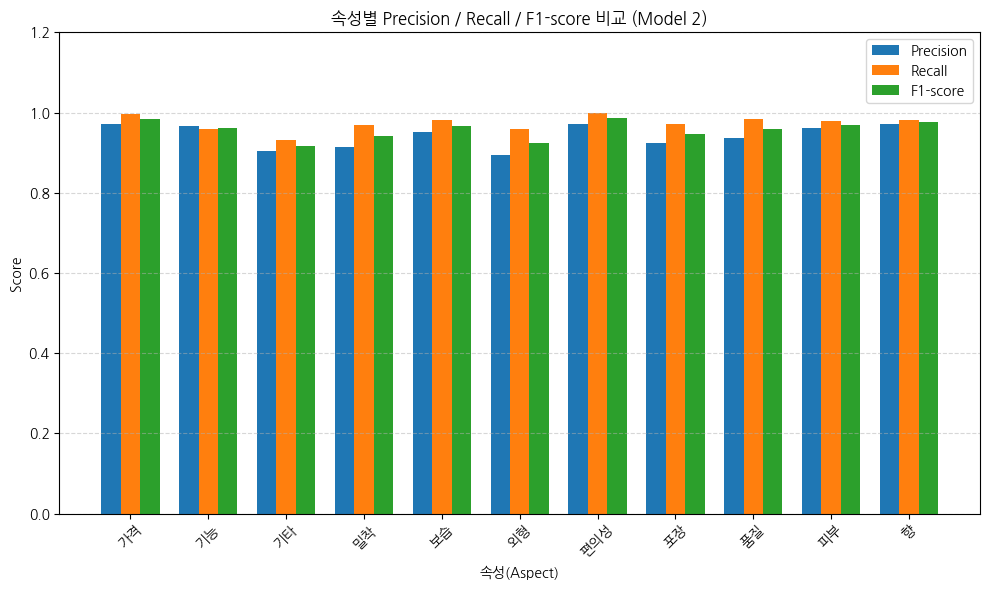

In [ ]:
plt.figure(figsize=(10,6))
x = np.arange(len(aspect_df2['aspect']))
width = 0.25

plt.bar(x - width, aspect_df2['precision'], width, label='Precision')
plt.bar(x, aspect_df2['recall'], width, label='Recall')
plt.bar(x + width, aspect_df2['f1'], width, label='F1-score')

plt.xticks(x, aspect_df2['aspect'], rotation=45)
plt.xlabel('속성(Aspect)')
plt.ylabel('Score')
plt.title('속성별 Precision / Recall / F1-score 비교 (Model 2)')
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3.방식② : 속성 : 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "ASPECT : 문장" 형태로 수정
    * 토크나이징

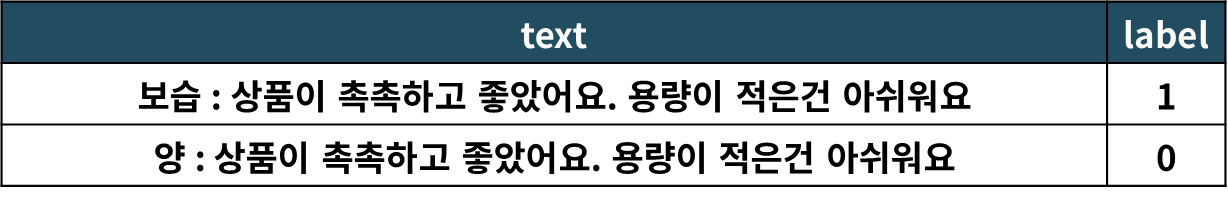

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
# train, val 데이터 분할
from sklearn.model_selection import train_test_split

train, val = train_test_split(data_sample, test_size=0.3,random_state=42)

In [ ]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

#### 2) 토크나이징
* "ASPECT : 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
tokenizer2 = AutoTokenizer.from_pretrained("klue/roberta-base")

In [ ]:
# 사용자 정의 스페셜 토큰 목록
special_tokens_dict = {"additional_special_tokens":["[ASPECT]"]}

# 토크나이저에 추가
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
print(f"Added {num_added_toks} special tokens: {special_tokens_dict['additional_special_tokens']}")

num_added_toks2 = tokenizer2.add_special_tokens(special_tokens_dict)
print(f"Added {num_added_toks2} special tokens: {special_tokens_dict['additional_special_tokens']}")

Added 1 special tokens: ['[ASPECT]']
Added 1 special tokens: ['[ASPECT]']


* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수
def preprocess_function(data):
  texts = [f"{a} : {t}" for a, t in zip(data['aspect'], data['text'])]

  tokenized = tokenizer(
      texts,
      truncation=True,
      padding='max_length',
      max_length=128
  )

  tokenized['labels'] = [float(l) for l in data['label']]

  return tokenized

# 모델1 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

# 모델2 전처리 함수
def preprocess_function2(data):
  texts = [f"{a} : {t}" for a, t in zip(data['aspect'], data['text'])]

  tokenized = tokenizer2(
      texts,
      truncation=True,
      padding='max_length',
      max_length=128
  )

  tokenized['labels'] = [float(l) for l in data['label']]

  return tokenized


# 모델2 전처리 적용
train_ts2= train_ts.map(preprocess_function2, batched=True)
val_ts2 = val_ts.map(preprocess_function2, batched=True)



Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
train_ts['labels']

Column([0.0, 1.0, 1.0, 1.0, 0.0])

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비

In [ ]:
# 모델1

num_labels = 2

model1 = AutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=num_labels
)

model1.resize_token_embeddings(len(tokenizer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=0)

In [ ]:
# 모델2

model2 = AutoModelForSequenceClassification.from_pretrained(
    model_name2,
    num_labels=num_labels
)

model2.resize_token_embeddings(len(tokenizer))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [ ]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:

# Trainer1 설정
trainer = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    #data_collator=float_label_collator,  # 오류 자주 발생.
    #compute_metrics=compute_metrics,     # 추가 측정 지표
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)


# Trainer2 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts2,
    eval_dataset = val_ts2,
    tokenizer = tokenizer2,
    #data_collator=float_label_collator,  # 오류 자주 발생.
    #compute_metrics=compute_metrics,     # 추가 측정 지표
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

/tmp/ipython-input-450870664.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/tmp/ipython-input-450870664.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.248100,0.256066
2,0.130300,0.208564
3,0.094600,0.195320
4,0.048000,0.254791
5,0.044100,0.274957


TrainOutput(global_step=1095, training_loss=0.13219893791768106, metrics={'train_runtime': 1092.6629, 'train_samples_per_second': 32.032, 'train_steps_per_second': 1.002, 'total_flos': 2302221734400000.0, 'train_loss': 0.13219893791768106, 'epoch': 5.0})

In [ ]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.202100,0.241232
2,0.127800,0.164818
3,0.120100,0.170692
4,0.068600,0.232524
5,0.051100,0.257304


TrainOutput(global_step=1095, training_loss=0.12601292591252827, metrics={'train_runtime': 1006.7658, 'train_samples_per_second': 34.765, 'train_steps_per_second': 1.088, 'total_flos': 2302221734400000.0, 'train_loss': 0.12601292591252827, 'epoch': 5.0})

#### 4) 모델 검증평가

* 예측

In [ ]:
raw_pred1 = trainer.predict(val_ts)

In [ ]:
pred1 = raw_pred1.predictions.argmax(axis=1)
true1 = raw_pred1.label_ids

In [ ]:
raw_pred2 = trainer2.predict(val_ts2)

In [ ]:
pred2 = raw_pred2.predictions.argmax(axis=1)
true2 = raw_pred2.label_ids

* 평가

In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val1 = val_ts.to_pandas()
val1['pred'] = pred1

# 일부 결과 확인
val1[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,ㅇㅇㅇ선스틱이 유명 한 건 알았는데 이전에 있는 제품은 끈적임이 있어서 개인적으로 ...,기능,1,1
1,여름 태양으로부터 모발을 보호하려고 구매했습니다. 냄새도 좋아요. 머릿결도 부드럽습...,향,1,1
2,어제 받아서 써봤는데 좋아요~ 엄청 촉촉하고 여기저기 쓱쓱 바르기 편해요 사이즈도 ...,보습,1,1
3,가성비좋아요 향도좋네요 묻어나네요ㅜ 시간 지나니 안묻어나네요ㅎ,가격,1,1
4,향이 가벼워서 아쉬운 것 같습니다. 겨울에는 사용하기 안 좋은 것 같습니다. 괜히 ...,향,0,0


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(true1, pred1, target_names=['부정','긍정'])
print(report)

              precision    recall  f1-score   support

          부정       0.89      0.86      0.87       830
          긍정       0.95      0.96      0.95      2170

    accuracy                           0.93      3000
   macro avg       0.92      0.91      0.91      3000
weighted avg       0.93      0.93      0.93      3000



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
# DataFrame 준비
df_eval = val1.copy()

aspect_scores = []

for aspect, group in df_eval.groupby('aspect'):
  y_true = group['label']
  y_pred = group['pred']
  p = precision_score(y_true, y_pred, zero_division=0)
  r = recall_score(y_true, y_pred, zero_division=0)
  f = f1_score(y_true, y_pred, zero_division=0)
  aspect_scores.append({'aspect': aspect, 'precision': p, 'recall': r, 'f1': f})

aspect_df = pd.DataFrame(aspect_scores)
print(aspect_df)

   aspect  precision    recall        f1
0      가격   0.980583  0.952830  0.966507
1      기능   0.960000  0.939759  0.949772
2      기타   0.855072  0.907692  0.880597
3      밀착   0.927419  0.982906  0.954357
4      보습   0.951807  0.975309  0.963415
5      외형   0.891892  0.891892  0.891892
6     편의성   0.963134  0.995238  0.978923
7      포장   0.927007  0.933824  0.930403
8      품질   0.948905  0.977444  0.962963
9      피부   0.960396  0.979798  0.970000
10      향   0.980861  0.966981  0.973872


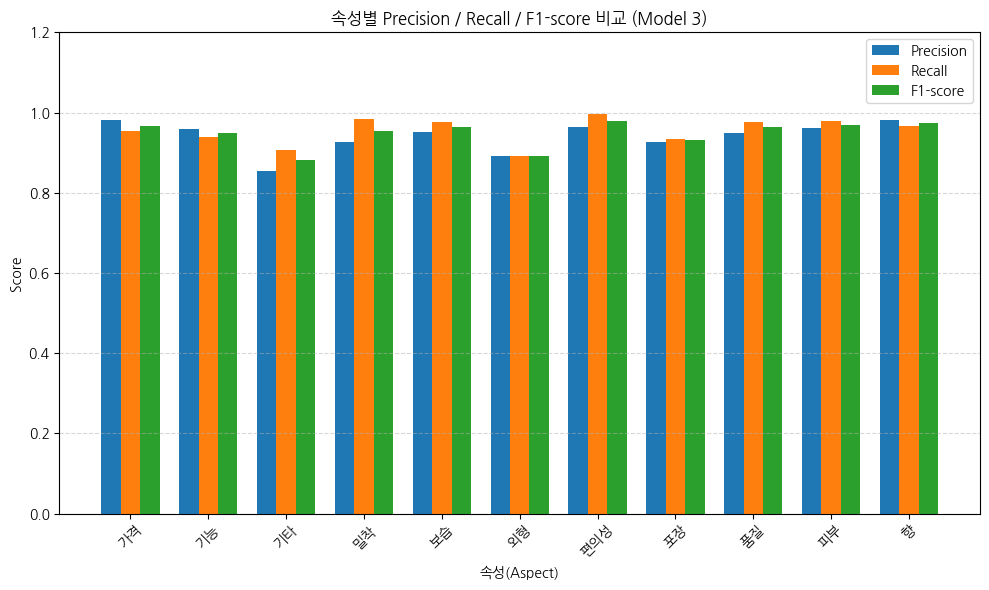

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
x = np.arange(len(aspect_df['aspect']))
width = 0.25

plt.bar(x - width, aspect_df['precision'], width, label='Precision')
plt.bar(x, aspect_df['recall'], width, label='Recall')
plt.bar(x + width, aspect_df['f1'], width, label='F1-score')

plt.xticks(x, aspect_df['aspect'], rotation=45)
plt.xlabel('속성(Aspect)')
plt.ylabel('Score')
plt.title('속성별 Precision / Recall / F1-score 비교 (Model 3)')
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#모델2

report = classification_report(true2, pred2, target_names=['부정','긍정'])
print(report)

              precision    recall  f1-score   support

          부정       0.93      0.86      0.89       830
          긍정       0.95      0.97      0.96      2170

    accuracy                           0.94      3000
   macro avg       0.94      0.92      0.93      3000
weighted avg       0.94      0.94      0.94      3000



In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val2 = val_ts2.to_pandas()
val2['pred'] = pred2

# 일부 결과 확인
val2[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,ㅇㅇㅇ선스틱이 유명 한 건 알았는데 이전에 있는 제품은 끈적임이 있어서 개인적으로 ...,기능,1,1
1,여름 태양으로부터 모발을 보호하려고 구매했습니다. 냄새도 좋아요. 머릿결도 부드럽습...,향,1,1
2,어제 받아서 써봤는데 좋아요~ 엄청 촉촉하고 여기저기 쓱쓱 바르기 편해요 사이즈도 ...,보습,1,1
3,가성비좋아요 향도좋네요 묻어나네요ㅜ 시간 지나니 안묻어나네요ㅎ,가격,1,1
4,향이 가벼워서 아쉬운 것 같습니다. 겨울에는 사용하기 안 좋은 것 같습니다. 괜히 ...,향,0,0


In [ ]:
# DataFrame 준비
df_eval = val2.copy()

aspect_scores = []

for aspect, group in df_eval.groupby('aspect'):
  y_true = group['label']
  y_pred = group['pred']
  p = precision_score(y_true, y_pred, zero_division=0)
  r = recall_score(y_true, y_pred, zero_division=0)
  f = f1_score(y_true, y_pred, zero_division=0)
  aspect_scores.append({'aspect': aspect, 'precision': p, 'recall': r, 'f1': f})

aspect_df2 = pd.DataFrame(aspect_scores)
print(aspect_df2)

   aspect  precision    recall        f1
0      가격   0.972350  0.995283  0.983683
1      기능   0.966565  0.957831  0.962179
2      기타   0.902985  0.930769  0.916667
3      밀착   0.915323  0.970085  0.941909
4      보습   0.952096  0.981481  0.966565
5      외형   0.893082  0.959459  0.925081
6     편의성   0.972222  1.000000  0.985915
7      포장   0.923077  0.970588  0.946237
8      품질   0.935714  0.984962  0.959707
9      피부   0.960396  0.979798  0.970000
10      향   0.971963  0.981132  0.976526


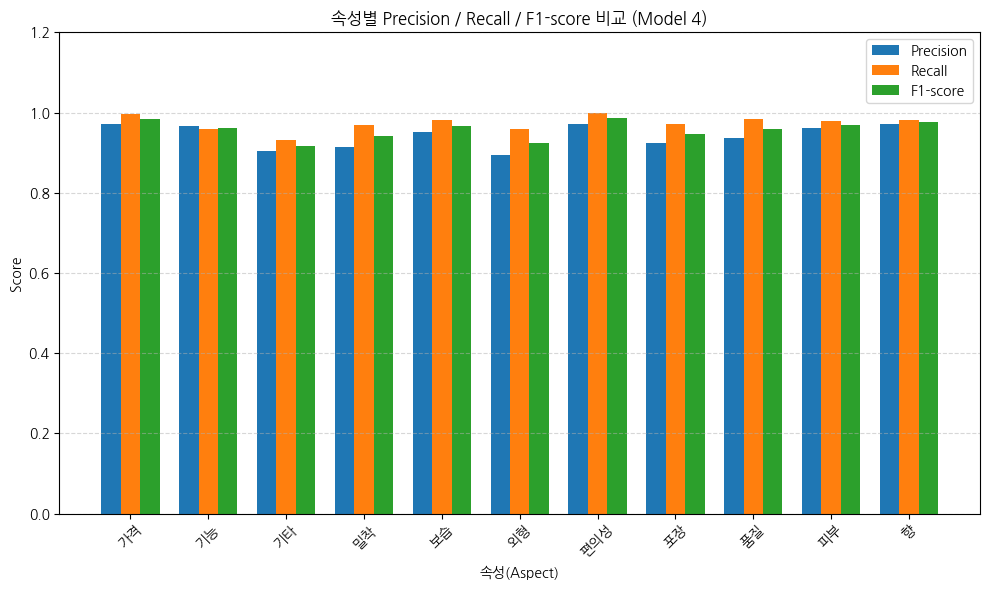

In [ ]:
plt.figure(figsize=(10,6))
x = np.arange(len(aspect_df2['aspect']))
width = 0.25

plt.bar(x - width, aspect_df2['precision'], width, label='Precision')
plt.bar(x, aspect_df2['recall'], width, label='Recall')
plt.bar(x + width, aspect_df2['f1'], width, label='F1-score')

plt.xticks(x, aspect_df2['aspect'], rotation=45)
plt.xlabel('속성(Aspect)')
plt.ylabel('Score')
plt.title('속성별 Precision / Recall / F1-score 비교 (Model 4)')
plt.ylim(0, 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 모델 성능비교

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.special import softmax, expit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score

os.makedirs("saved_preds", exist_ok=True)

def logits_to_probs(logits):
    logits = np.asarray(logits)
    if logits.ndim == 2 and logits.shape[1] == 2:
        return softmax(logits, axis=1)[:,1]
    if logits.ndim == 2 and logits.shape[1] == 1:
        return expit(logits[:,0])
    if logits.ndim == 1:
        return expit(logits)
    return softmax(logits, axis=1)[:,-1]

def eval_and_save(trainer, name, outdir="saved_preds", threshold=0.5):
    raw = trainer.predict(getattr(trainer, "eval_dataset"))
    logits = raw.predictions
    labels = raw.label_ids
    probs = logits_to_probs(logits)
    preds = (probs >= threshold).astype(int)

    # metrics
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except:
        roc_auc = np.nan
    try:
        pr_auc = average_precision_score(labels, probs)
    except:
        pr_auc = np.nan

    metrics = {
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else None,
        'pr_auc': float(pr_auc) if not np.isnan(pr_auc) else None,
        'n_samples': int(len(labels))
    }

    # 1) save arrays compressed (npz)
    np.savez_compressed(os.path.join(outdir, f"{name}_preds.npz"),
                        probs=probs.astype(np.float32),
                        preds=preds.astype(np.int8),
                        labels=labels.astype(np.int8))

    # 2) save metrics as json/csv line
    metrics_df = pd.DataFrame([{'model': name, **metrics}])
    metrics_df.to_csv(os.path.join(outdir, "metrics_summary.csv"), mode='a', header=not os.path.exists(os.path.join(outdir, "metrics_summary.csv")), index=False)

    # (선택) 3) save full table (parquet) — 디버깅/리뷰용
    df = pd.DataFrame({'prob': probs, 'pred': preds, 'label': labels})
    df.to_parquet(os.path.join(outdir, f"{name}_table.parquet"))

    print(f"Saved {name} -> {outdir}")
    return metrics

# 사용 예:
# trainers = [trainer1, trainer2, trainer3, trainer4]
# names = ['m1','m2','m3','m4']
# for tr, nm in zip(trainers, names):
#     eval_and_save(tr, nm)


In [ ]:
# 사용 예:
trainers = [trainer1, trainer2]
names = ['m3','m4']
for tr, nm in zip(trainers, names):
    eval_and_save(tr, nm)

Saved m3 -> saved_preds


Saved m4 -> saved_preds



=== Summary ===
  model  n_samples  accuracy  precision    recall        f1   roc_auc  \
0    m2       2000    0.9235   0.936738  0.973462  0.954747  0.958578   
1    m4       2000    0.9150   0.930556  0.969843  0.949793  0.954431   
2    m1       2000    0.9060   0.920481  0.970446  0.944803  0.943056   
3    m3       2000    0.9145   0.929521  0.970446  0.949543  0.943194   

     pr_auc     brier  
0  0.990637  0.060317  
1  0.989200  0.060237  
2  0.987242  0.067634  
3  0.986691  0.066522  


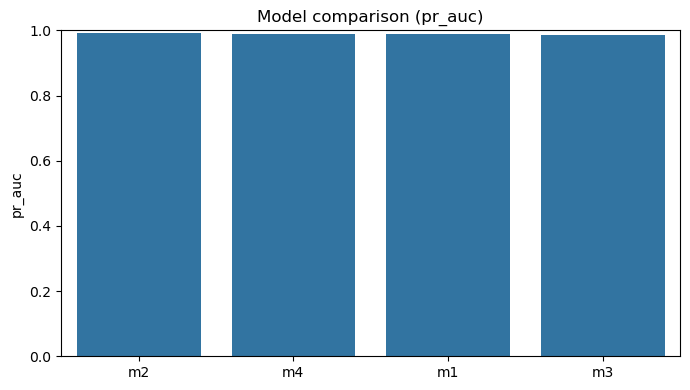

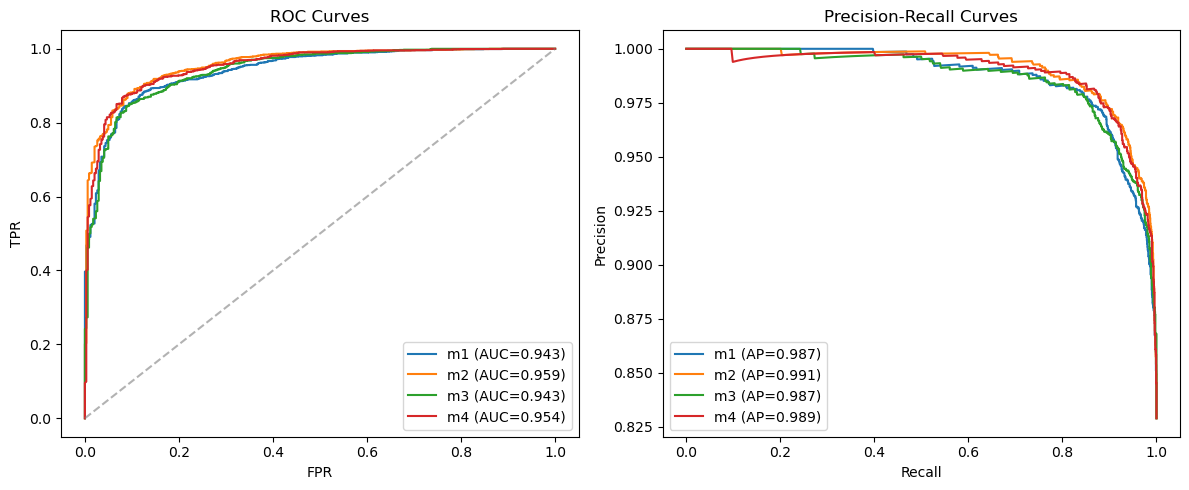

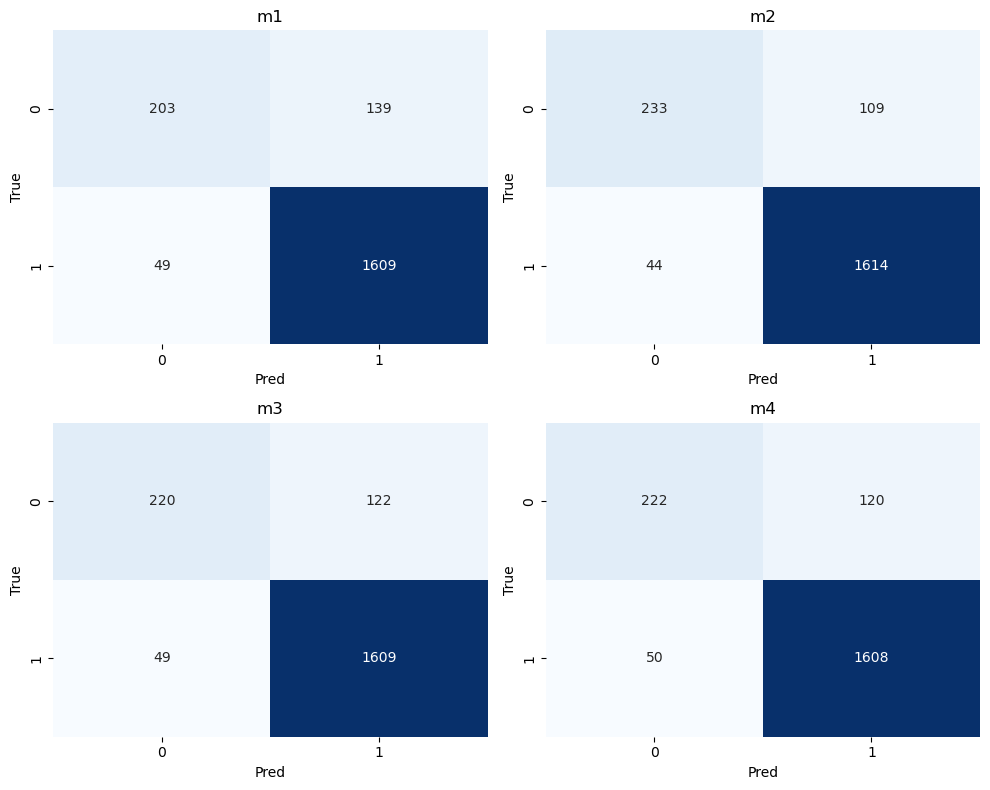

In [ ]:
# saved_preds 시각화 도구
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax, expit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, average_precision_score, confusion_matrix,
    brier_score_loss, roc_curve, precision_recall_curve, auc
)

SAVED_DIR = "data"  # 저장된 폴더
MODELS = ['m1','m2','m3','m4']  # 불러올 모델 이름 리스트

# 유틸: npz 파일에서 probs, preds, labels 불러오기
def load_npz_predictions(model_name, outdir=SAVED_DIR):
    path = os.path.join(outdir, f"{model_name}_preds.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    arr = np.load(path)
    probs = arr['probs']
    preds = arr['preds']
    labels = arr['labels']
    return probs, preds, labels

# 유틸: metrics 계산
def compute_metrics_from_arrays(probs, preds, labels):
    metrics = {}
    metrics['accuracy'] = float(accuracy_score(labels, preds))
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    metrics['precision'] = float(p)
    metrics['recall'] = float(r)
    metrics['f1'] = float(f1)
    # ROC-AUC / PR-AUC 계산 (single-class 예외 처리)
    try:
        metrics['roc_auc'] = float(roc_auc_score(labels, probs))
    except Exception:
        metrics['roc_auc'] = float('nan')
    try:
        metrics['pr_auc'] = float(average_precision_score(labels, probs))
    except Exception:
        metrics['pr_auc'] = float('nan')
    # brier
    try:
        metrics['brier'] = float(brier_score_loss(labels, probs))
    except Exception:
        metrics['brier'] = float('nan')
    metrics['n_samples'] = int(len(labels))
    return metrics

# 시각화: 요약표 및 막대그래프
def summarize_and_plot(models=MODELS, primary_metric='pr_auc', outdir=SAVED_DIR, show_table=True):
    rows = []
    results = {}
    for m in models:
        probs, preds, labels = load_npz_predictions(m, outdir)
        metrics = compute_metrics_from_arrays(probs, preds, labels)
        rows.append({'model': m, **metrics})
        results[m] = {'probs':probs, 'preds':preds, 'labels':labels, **metrics}
    df = pd.DataFrame(rows).sort_values(by=primary_metric, ascending=False).reset_index(drop=True)

    if show_table:
        print("\n=== Summary ===")
        print(df[['model','n_samples','accuracy','precision','recall','f1','roc_auc','pr_auc','brier']])

    # 막대그래프 (primary metric)
    plt.figure(figsize=(7,4))
    sns.barplot(data=df, x='model', y=primary_metric)
    plt.ylim(0,1)
    plt.title(f"Model comparison ({primary_metric})")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

    return results, df

# 시각화: ROC/PR 곡선
def plot_roc_pr_for_results(results):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for name, r in results.items():
        labels = r['labels']; probs = r['probs']
        if len(np.unique(labels))==1:
            continue
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc = roc_auc_score(labels, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--', color='gray', alpha=0.6)
    plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

    plt.subplot(1,2,2)
    for name, r in results.items():
        labels = r['labels']; probs = r['probs']
        if len(np.unique(labels))==1:
            continue
        prec, rec, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.title("Precision-Recall Curves"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
    plt.tight_layout()
    plt.show()

# 시각화: 혼동행렬 여러개 한 번에
def plot_confusion_matrices(results):
    names = list(results.keys())
    n = len(names)
    cols = min(2, n)
    rows = (n + cols - 1)//cols
    plt.figure(figsize=(5*cols, 4*rows))
    for i, name in enumerate(names):
        cm = confusion_matrix(results[name]['labels'], results[name]['preds'])
        plt.subplot(rows, cols, i+1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(name)
        plt.xlabel('Pred'); plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ========== 실행 예시 ==========
results, summary_df = summarize_and_plot(models=MODELS, primary_metric='pr_auc', outdir=SAVED_DIR)
plot_roc_pr_for_results(results)
plot_confusion_matrices(results)
